In [1]:
print("OK")

OK


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Social_Network_Ads.csv")

In [5]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
df=df.iloc[:,2:]

In [7]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [16]:
df.sample(5)

,Age,EstimatedSalary,Purchased
0,19,19000,0
208,40,142000,1
378,41,87000,1
90,22,81000,0
178,24,23000,0


In [17]:
df.shape

(400, 3)

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(df.drop('Purchased', axis=1),df['Purchased'],test_size=0.3, random_state=42)      # df[['Purchased']]

In [28]:
x_train.shape, x_test.shape

((280, 2), (120, 2))

In [29]:
y_train.shape ,y_test.shape

((280, 1), (120, 1))

In [30]:
x_train

,Age,EstimatedSalary
157,29,75000
109,38,80000
17,45,26000
347,54,108000
24,46,23000
...,...,...
71,24,27000
106,26,35000
270,43,133000
348,39,77000


In [32]:
y_train

,Purchased
157,0
109,0
17,1
347,1
24,1
...,...
71,0
106,0
270,0
348,0


In [34]:
x_test

,Age,EstimatedSalary
209,46,22000
280,59,88000
33,28,44000
210,48,96000
93,29,28000
...,...,...
60,27,20000
79,26,17000
285,37,93000
305,42,54000


In [35]:
y_test

,Purchased
209,0
280,1
33,0
210,1
93,0
...,...
60,0
79,0
285,1
305,0


## StandardScaler

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters

scaler.fit(x_train)

# Transform train and test
x_train_scaler=scaler.transform(x_train)
x_test_scaler=scaler.transform(x_test)

In [42]:
scaler.mean_

array([3.75750000e+01, 7.05892857e+04])

In [41]:
x_train

,Age,EstimatedSalary
157,29,75000
109,38,80000
17,45,26000
347,54,108000
24,46,23000
...,...,...
71,24,27000
106,26,35000
270,43,133000
348,39,77000


In [49]:
#x_train_scaler


In [43]:
x_train_scaler =pd.DataFrame(x_train_scaler, columns=x_train.columns)
x_test_scaler=pd.DataFrame(x_test_scaler, columns=x_test.columns)

In [45]:
x_train_scaler.head()

,Age,EstimatedSalary
0,-0.842522,0.130156
1,0.041758,0.277702
2,0.729530,-1.315791
3,1.613809,1.103957
4,0.827784,-1.404318


In [46]:
x_test_scaler.head()

,Age,EstimatedSalary
0,0.827784,-1.433827
1,2.105076,0.513775
2,-0.940775,-0.784626
3,1.024290,0.749848
4,-0.842522,-1.256772


In [50]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.6,70589.3
std,10.2,33948.5
min,18.0,15000.0
25%,30.0,44000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [51]:
np.round(x_train_scaler.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


In [52]:
x_train_scaler.head()

,Age,EstimatedSalary
0,-0.842522,0.130156
1,0.041758,0.277702
2,0.729530,-1.315791
3,1.613809,1.103957
4,0.827784,-1.404318


## Effect of Scaling

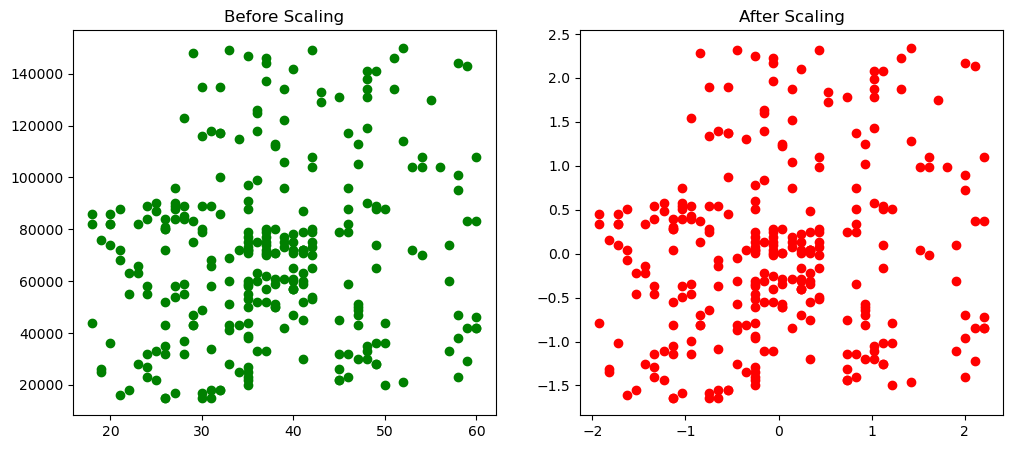

In [63]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['Age'],x_train['EstimatedSalary'],color='Green')
ax1.set_title("Before Scaling")

ax2.scatter(x_train_scaler['Age'], x_train_scaler['EstimatedSalary'],color='red')
ax2.set_title('After Scaling')
plt.show()


<Axes: title={'center': 'After Scaling'}, xlabel='Age', ylabel='Density'>

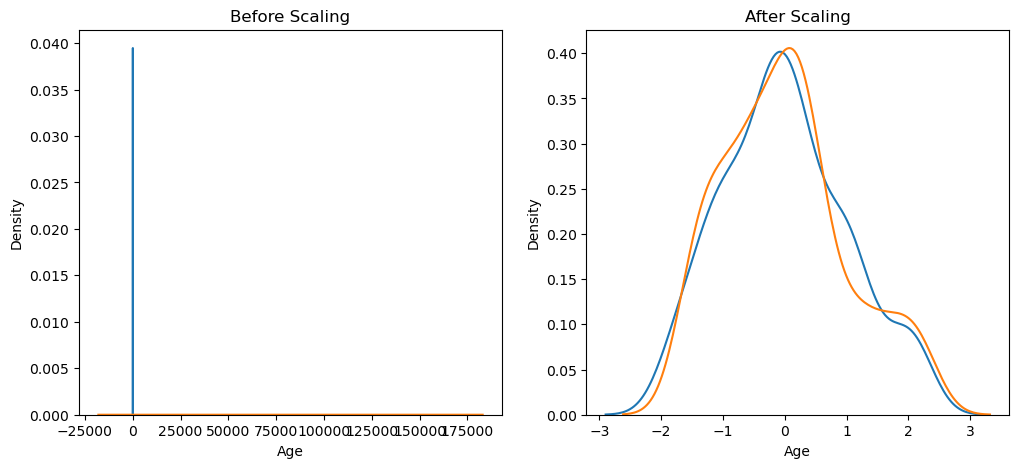

In [64]:
fig,(ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'],ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# After scaling
ax2.set_title("After Scaling")
sns.kdeplot(x_train_scaler['Age'], ax=ax2)
sns.kdeplot(x_train_scaler['EstimatedSalary'],ax=ax2)

# Comparidon Distribution 

<Axes: title={'center': 'Age Distribution After Scaling'}, xlabel='Age', ylabel='Density'>

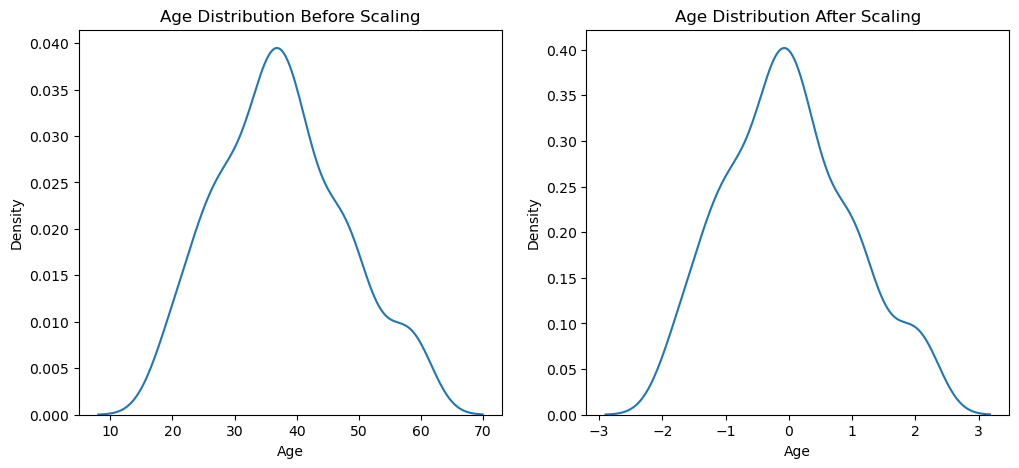

In [72]:
fig, (ax1, ax2)=plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Age Distribution Before Scaling")
sns.kdeplot(x_train['Age'], ax=ax1)

ax2.set_title("Age Distribution After Scaling")
sns.kdeplot(x_train_scaler['Age'], ax=ax2)

<Axes: title={'center': 'AEstimatedSalaryge Distribution After Scaling'}, xlabel='EstimatedSalary', ylabel='Density'>

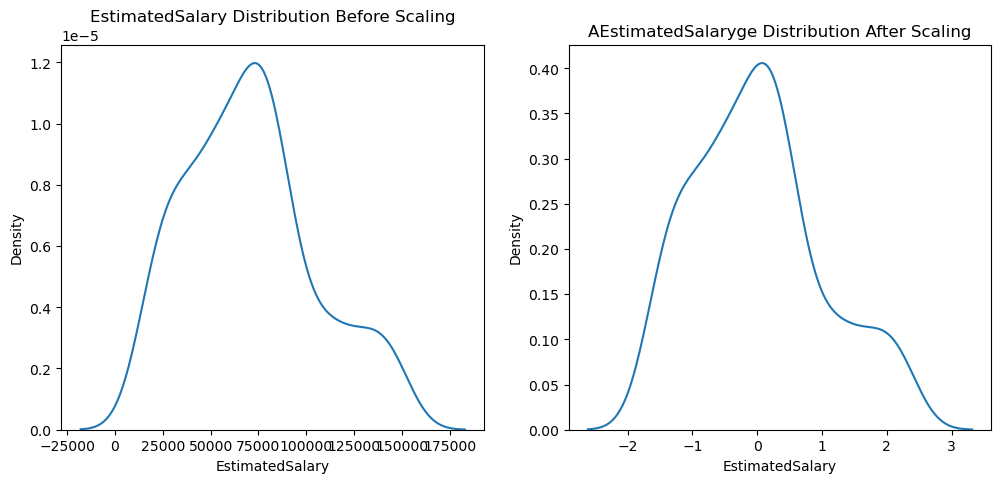

In [73]:
fig, (ax1, ax2)=plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("EstimatedSalary Distribution Before Scaling")
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

ax2.set_title("AEstimatedSalaryge Distribution After Scaling")
sns.kdeplot(x_train_scaler['EstimatedSalary'], ax=ax2)

## Why Scaling is Important?? 

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
lr=LogisticRegression()
lr_scaler=LogisticRegression()

In [77]:
lr.fit(x_train, y_train)
lr_scaler.fit(x_train_scaler,y_train)

d:\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [78]:
y_pred=lr.predict(x_test)
y_pred_scaler=lr_scaler.predict(x_test_scaler)

In [84]:
from sklearn.metrics import accuracy_score

In [ ]:
print("Actual", accuracy_score(y_test,y_pred))
print("Scaled Accuracy", accuracy_score(y_test,y_pred_scaler))

Actual 0.85
 Scaled Accuracy 0.85


## Decision Tree

In [86]:
from sklearn.tree import DecisionTreeClassifier

In [88]:
dt=DecisionTreeClassifier()
dt_scaler=DecisionTreeClassifier()

In [89]:
dt.fit(x_train,y_train)
dt_scaler.fit(x_train_scaler, y_train)

DecisionTreeClassifier()

In [90]:
y_pred=dt.predict(x_test)
y_pred_scaler=dt_scaler.predict(x_test_scaler)

In [94]:
print("Accuracy", accuracy_score(y_test,y_pred))
print("Scaled", accuracy_score(y_test,y_pred_scaler))

Accuracy 0.85
Scaled 0.8416666666666667


In [95]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


# Effect of Outlier

In [96]:
import pandas as pd

# New data to add
new_data = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased': [0, 1, 1]
})

# Use pd.concat instead of append
df = pd.concat([df, new_data], ignore_index=True)

In [97]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


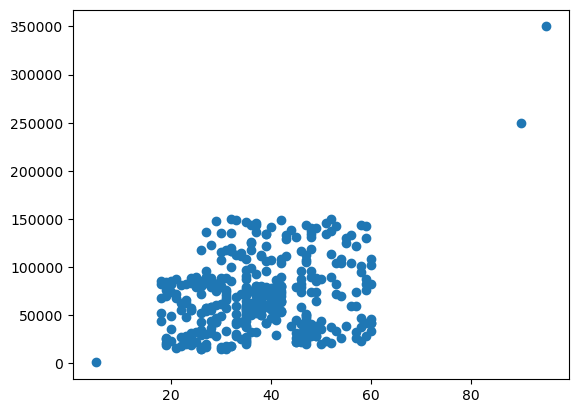

In [98]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [99]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((282, 2), (121, 2))

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [101]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

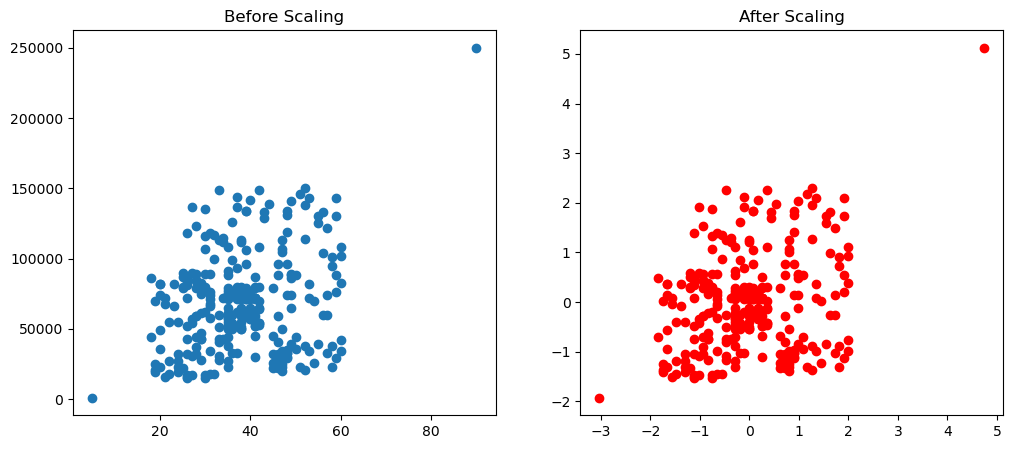

In [102]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()